In [4]:
 import tensorflow as tf
 from tensorflow import keras
 import numpy as np
 import matplotlib.pyplot as plt

In [5]:
 # Load the Fashion MNIST dataset
 fashion_mnist = keras.datasets.fashion_mnist
 (train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
 # Normalize the images to a [0, 1] range
 train_images = train_images / 255.0
 test_images = test_images / 255.0

In [7]:
 # Class names for readability in plots
 class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [8]:
 # Define the model architecture
 model = keras.Sequential([
 keras.layers.Flatten(input_shape=(28, 28)),
 keras.layers.Dense(128, activation='relu'),
 keras.layers.Dense(10, activation='softmax')  # Output layer for 10 classes
 ])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
 # Compile the model
 model.compile(
 optimizer='adam',
 loss='sparse_categorical_crossentropy',
 metrics=['accuracy']
 )

In [10]:
 # Train the model
 model.fit(train_images, train_labels, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7702 - loss: 0.6621 - val_accuracy: 0.8503 - val_loss: 0.4218
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8580 - loss: 0.3956 - val_accuracy: 0.8553 - val_loss: 0.3993
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8728 - loss: 0.3506 - val_accuracy: 0.8760 - val_loss: 0.3517
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8818 - loss: 0.3234 - val_accuracy: 0.8812 - val_loss: 0.3332
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8907 - loss: 0.2989 - val_accuracy: 0.8722 - val_loss: 0.3503
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8956 - loss: 0.2807 - val_accuracy: 0.8799 - val_loss: 0.3299
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9009 - loss: 0.2693 - val_accuracy: 0.8832 - val_loss: 0.3208
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9038 - loss: 0.2595

In [11]:
 # Evaluate the model
 test_loss, test_acc = model.evaluate(test_images, test_labels)
 print('\n✅Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8812 - loss: 0.3413

✅Test accuracy: 0.8810999989509583


In [12]:
 # Make predictions
 predictions = model.predict(test_images)
 predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


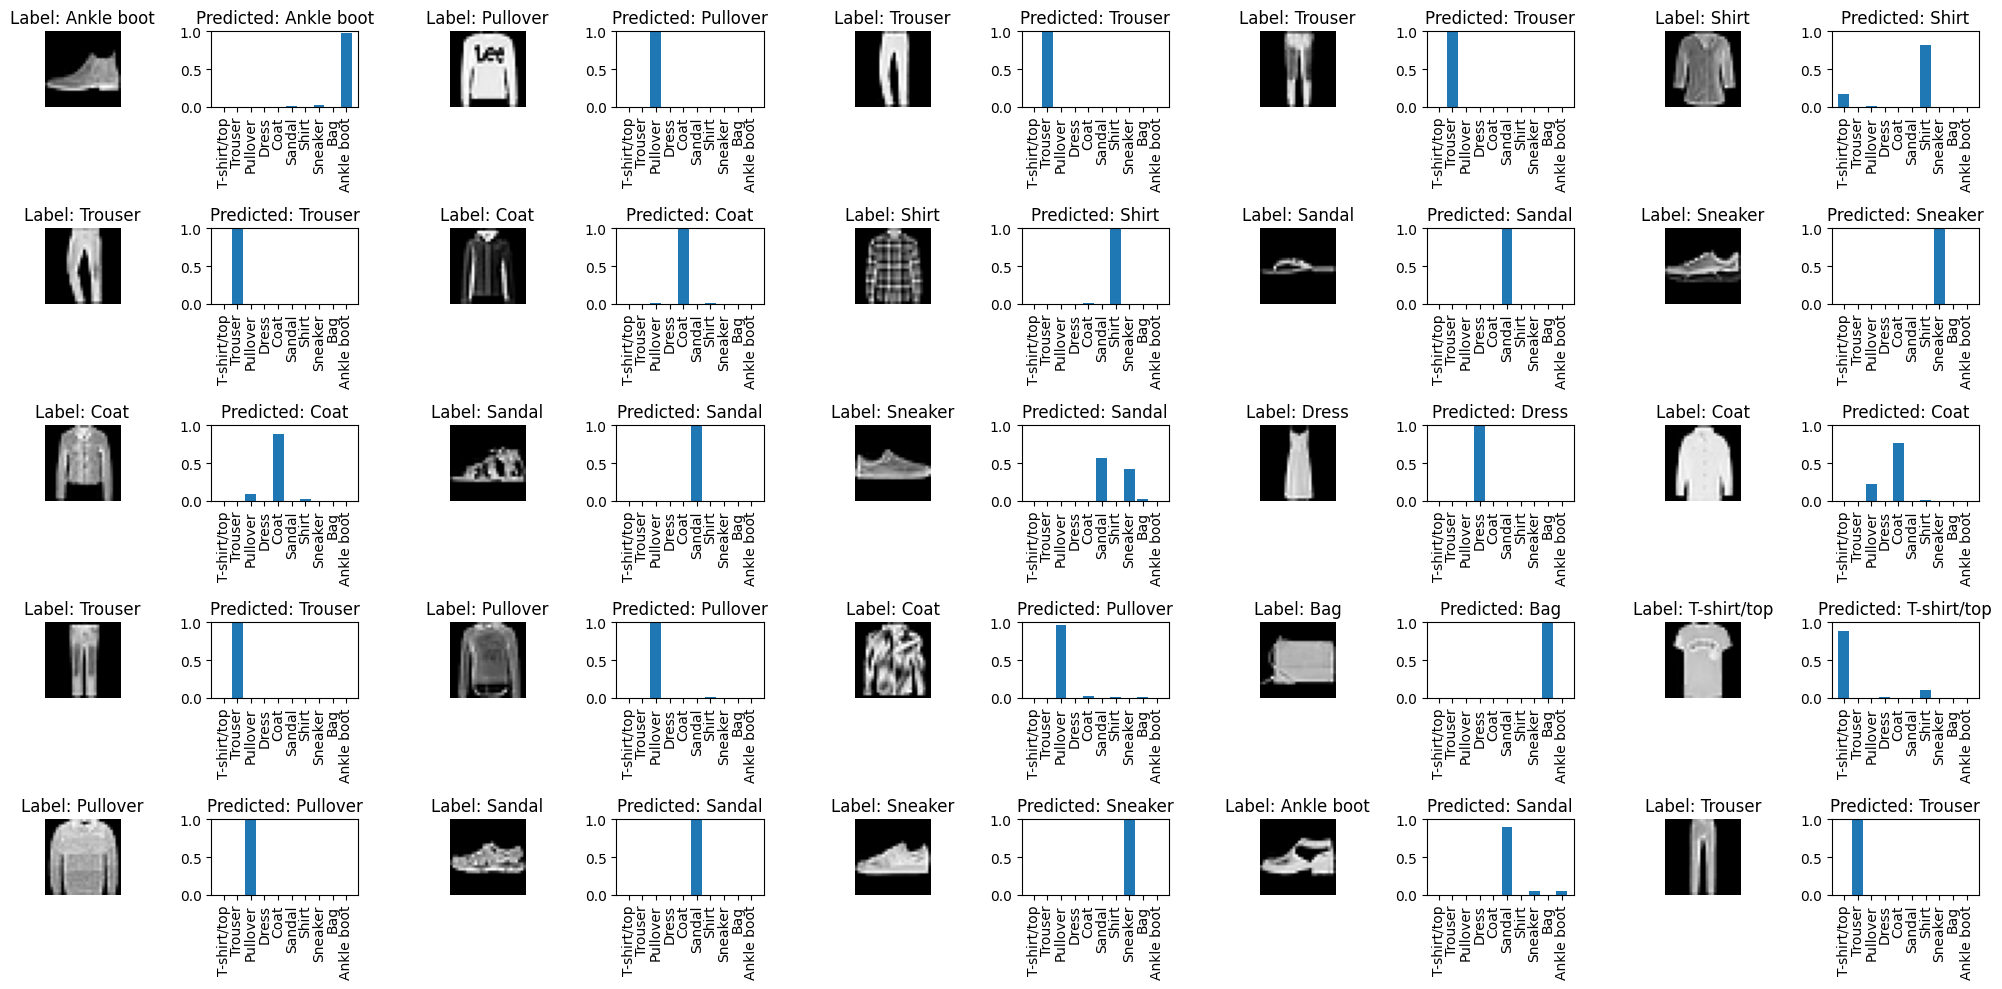

In [14]:
 # Plot predictions for a few test images
 num_rows = 5
 num_cols = 5
 num_images = num_rows * num_cols
 plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))

 for i in range(num_images):
 # Plot image

  plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
  plt.imshow(test_images[i], cmap='gray')
  plt.axis('off')
  plt.title(f"Label: {class_names[test_labels[i]]}")
 # Plot prediction probabilities
  plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
  plt.bar(range(10), predictions[i])
  plt.xticks(range(10), class_names, rotation=90)
  plt.ylim([0, 1])
  plt.title(f"Predicted: {class_names[predicted_labels[i]]}")
 plt.tight_layout()
 plt.show()